In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Donchian Channel Breakout — Signal Research

**Instruments:** SPY, QQQ, IWM (daily bars)
**Signal:** Long entry when close >= upper channel (N-day high). Trend-following.
**Entry:** Next day's open (avoids lookahead on close-triggered breakout).
**Exit:** Close of the day that hits lower channel (N-day low), subject to min hold. Or stop loss.
**Direction:** Long-only.

**This notebook:**
1. Signal engine with grid-searchable parameters
2. Grid search: channel_period x min_hold_days x stop_loss
3. Significance tests (gross & net)
4. Simple equity curve
5. Overlap analysis (do SPY/QQQ/IWM fire independently?)
6. Save standardized trades

**Sizing & implementation comparison** -> see `Donchian_Channel_Implementation.ipynb`

**Parameter selection:** Channel period, min hold, and stop loss are grid-searched
with stability analysis. Default period=20 is the Turtle Trading System standard
(Richard Dennis, 1983). Min hold=30 avoids whipsaw entries.

**Academic backing:** Donchian channel breakout is one of the oldest documented
systematic strategies (Richard Donchian, 1960s). The 20-day variant was validated
by the Turtle experiment and documented in Curtis Faith's 'Way of the Turtle' (2007).
AQR's 'A Century of Evidence on Trend-Following Investing' (2014) provides
cross-asset, multi-decade academic validation of trend-following.

## 1. Setup

In [46]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.implementations import build_daily_equity, build_multi_sleeve_equity
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [47]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOLS    = ["SPY", "QQQ", "IWM"]
START_DATE = "2006-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1
STRATEGY_NAME    = "Donchian Channel"
SAVE_NAME        = "donchian_channel"
BET_SIZE         = 0.85

## 2. Data Fetching

In [48]:
data_dict = fetch_historical_data(
    SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

all_data = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} -> {d['date'].iloc[-1].date()}")

Fetching SPY...
  2,575 bars
Fetching QQQ...
  2,575 bars
Fetching IWM...
  2,575 bars
SPY: 2,575 bars, 2016-01-04 -> 2026-03-31
QQQ: 2,575 bars, 2016-01-04 -> 2026-03-31
IWM: 2,575 bars, 2016-01-04 -> 2026-03-31


## 3. Signal Engine

Generates raw trades -- **no position sizing, no equity tracking.**

**Entry:** Next day's open after close >= upper channel (N-day high, shifted 1 day).
**Exit:** Close of the day that close <= lower channel (N-day low, shifted 1 day),
subject to min_hold_days. Or stop loss if hit first.

Note: `.shift(1)` on upper/lower uses yesterday's channel -- no lookahead on the channel itself.
The next-day-open entry avoids lookahead on the close-based breakout detection.

In [49]:
def generate_signals(all_data, channel_period, min_hold_days=0, stop_loss=None):
    """
    Generate raw Donchian Channel breakout trades -- signal only, no sizing.

    Entry: next day's open after close >= upper channel.
    Exit:  close of the day where close <= lower channel AND days held >= min_hold_days.
           Or stop loss (close <= entry * (1 + stop_loss)).
           Falls back to end_of_data if never triggered.

    Returns DataFrame with standardized columns:
        entry_time, exit_time, direction, instrument, entry_price,
        exit_price, pct_return_gross, exit_reason, stop_price
    """
    trades = []

    for sym, df in all_data.items():
        df = df.copy()
        df["upper"] = df["high"].rolling(window=channel_period).max().shift(1)
        df["lower"] = df["low"].rolling(window=channel_period).min().shift(1)
        df = df.dropna(subset=["upper", "lower"]).reset_index(drop=True)

        in_pos = False
        entry_price = entry_time = stop_price = None

        for i in range(len(df)):
            row = df.iloc[i]

            if not in_pos:
                if row["close"] >= row["upper"]:
                    # Signal triggered -- entry at NEXT day's open
                    if i + 1 < len(df):
                        next_row = df.iloc[i + 1]
                        in_pos = True
                        entry_price = next_row["open"]
                        entry_time  = next_row["date"]
                        if stop_loss is not None:
                            stop_price = entry_price * (1 + stop_loss)
                        else:
                            stop_price = np.nan
            else:
                days_held = (row["date"] - entry_time).days

                # Stop loss check (always active, regardless of min_hold)
                if stop_loss is not None and row["close"] <= entry_price * (1 + stop_loss):
                    exit_price = entry_price * (1 + stop_loss)
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       entry_time,
                        "exit_time":        row["date"],
                        "direction":        "long",
                        "instrument":       sym,
                        "entry_price":      round(entry_price, 4),
                        "exit_price":       round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason":      "stop_loss",
                        "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
                    })
                    in_pos = False
                    continue

                # Normal exit: lower channel breach after min hold
                if row["close"] <= row["lower"] and days_held >= min_hold_days:
                    exit_price = row["close"]
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       entry_time,
                        "exit_time":        row["date"],
                        "direction":        "long",
                        "instrument":       sym,
                        "entry_price":      round(entry_price, 4),
                        "exit_price":       round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason":      "lower_channel",
                        "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
                    })
                    in_pos = False

        # Close open position at end of data
        if in_pos:
            row = df.iloc[-1]
            exit_price = row["close"]
            pct_return_gross = (exit_price - entry_price) / entry_price
            trades.append({
                "entry_time":       entry_time,
                "exit_time":        row["date"],
                "direction":        "long",
                "instrument":       sym,
                "entry_price":      round(entry_price, 4),
                "exit_price":       round(exit_price, 4),
                "pct_return_gross": round(pct_return_gross, 6),
                "exit_reason":      "end_of_data",
                "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
            })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)

## 4. Parameter Grid Search

Sweep channel_period, min_hold_days, and stop_loss.
Uses `calculate_fees_pct` for net Sharpe.

In [50]:
param_grid = {
    "channel_period": [10, 20, 30, 50],
    "min_hold_days":  [0, 10, 20, 30],
    "stop_loss":      [None, -0.03, -0.05, -0.08, -0.10],
}

param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
print(f"Total combinations: {len(all_combos)}")

grid_results = []
for combo in all_combos:
    params = dict(zip(param_keys, combo))
    try:
        res = generate_signals(all_data, **params)
        if res.empty or len(res) < 5:
            continue
        fee_pcts = res.apply(
            lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
        rets = res["pct_return_gross"] - fee_pcts
        n = len(rets)
        wins = (rets > 0).sum()
        total_ret = ((1 + rets).prod() - 1) * 100
        sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
        eq = STARTING_CAPITAL * (1 + rets).cumprod()
        max_dd = ((eq - eq.expanding().max()) / eq.expanding().max()).min() * 100
        pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf
        avg_hold = (res["exit_time"] - res["entry_time"]).dt.days.mean()

        grid_results.append({
            **params,
            "Trades": n, "Win Rate": round(wins/n*100, 1),
            "Total Return": round(total_ret, 1),
            "Sharpe": round(sharpe, 2), "Max Drawdown": round(max_dd, 1),
            "Profit Factor": round(pf, 2),
            "Avg Hold": round(avg_hold, 1),
        })
    except Exception as e:
        print(f"Skipped {params}: {e}")

grid_df = pd.DataFrame(grid_results)
print(f"Completed: {len(grid_results)}")

# Correct Sharpe for actual holding period: sqrt(252/avg_hold) not sqrt(252)
grid_df["sharpe_corrected"] = grid_df.apply(
    lambda r: r["Sharpe"] * 1.0 / np.sqrt(max(r["Avg Hold"], 1))
              if r["Sharpe"] > 0 else r["Sharpe"], axis=1
).round(2)


Total combinations: 80
Completed: 80


In [51]:
if not grid_df.empty:
    display_cols = ["channel_period", "min_hold_days", "stop_loss",
                    "sharpe_corrected", "Total Return", "Max Drawdown",
                    "Win Rate", "Profit Factor", "Trades", "Avg Hold"]
    available = [c for c in display_cols if c in grid_df.columns]
    top = grid_df.sort_values("sharpe_corrected", ascending=False).head(20)
    print("TOP PARAMETER COMBINATIONS (by corrected Sharpe):")
    print("=" * 140)
    print(top[available].to_string(index=False))
    print("\n(sharpe_corrected = annualized from daily, accounting for avg hold period)")

    best_row = grid_df.loc[grid_df["sharpe_corrected"].idxmax()]
    print(f"\nBest: channel_period={int(best_row['channel_period'])}, "
          f"min_hold={int(best_row['min_hold_days'])}d, stop={best_row['stop_loss']}")

    # Sensitivity tables
    print("\n\nCHANNEL PERIOD SENSITIVITY (at best min_hold/stop):")
    print("=" * 140)
    mask = ((grid_df["min_hold_days"] == best_row["min_hold_days"]) &
            (grid_df["stop_loss"].fillna('none') == (best_row["stop_loss"] if pd.notna(best_row["stop_loss"]) else 'none')))
    print(grid_df[mask].sort_values("sharpe_corrected", ascending=False)[available].to_string(index=False))

    print("\n\nSTOP LOSS SENSITIVITY (at best period/min_hold):")
    print("=" * 140)
    mask = ((grid_df["channel_period"] == best_row["channel_period"]) &
            (grid_df["min_hold_days"] == best_row["min_hold_days"]))
    print(grid_df[mask].sort_values("sharpe_corrected", ascending=False)[available].to_string(index=False))


TOP PARAMETER COMBINATIONS (by corrected Sharpe):
 channel_period  min_hold_days  stop_loss  sharpe_corrected  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades  Avg Hold
             20             30      -0.08              0.82        2215.7         -36.4      70.0           4.62      80      94.0
             20             30      -0.05              0.80        1958.8         -28.2      66.7           4.33      84      88.3
             20             30        NaN              0.78        2030.0         -41.7      69.2           4.50      78      98.3
             20             30      -0.10              0.78        2018.9         -40.5      70.0           4.26      80      94.5
             20             20      -0.08              0.77        1771.2         -33.7      65.9           4.05      85      86.9
             20             20        NaN              0.76        1742.4         -29.5      65.5           4.09      84      88.5
             20             20   

In [52]:
# =============================================================================
# PARAMETER STABILITY ANALYSIS — trade-count weighted
# =============================================================================
# Finds parameters that are consistently good (not just best in one combo).
# Penalizes low trade counts to avoid overfitting to thin samples.

print("=" * 80)
print("PARAMETER STABILITY ANALYSIS (trade-count weighted)")
print("=" * 80)
print("Score = avg rank, penalized for <50 trades.\n")

grid_df["rank"] = grid_df["sharpe_corrected"].rank(ascending=False)
grid_df["weighted_rank"] = grid_df["rank"] * (50 / grid_df["Trades"].clip(upper=50))

for param in ["channel_period", "min_hold_days", "stop_loss"]:
    print(f"\n-- {param} --")
    summary = grid_df.groupby(param).agg(
        avg_wrank=("weighted_rank", "mean"),
        avg_sharpe_c=("sharpe_corrected", "mean"),
        min_sharpe_c=("sharpe_corrected", "min"),
        max_sharpe_c=("sharpe_corrected", "max"),
        avg_trades=("Trades", "mean"),
    ).round(2)
    summary = summary.sort_values("avg_wrank")
    print(summary.to_string())

print("\n" + "=" * 80)
print("RECOMMENDED STABLE PARAMETERS")
print("=" * 80)
stable = {}
for param in ["channel_period", "min_hold_days", "stop_loss"]:
    best_val = grid_df.groupby(param)["weighted_rank"].mean().idxmin()
    avg_wr = grid_df.groupby(param)["weighted_rank"].mean().min()
    avg_tr = grid_df.groupby(param).apply(
        lambda g: g["Trades"].mean()).loc[best_val] if not pd.isna(best_val) else \
        grid_df[grid_df[param].isna()]["Trades"].mean()
    stable[param] = best_val
    print(f"  {param}: {best_val} (avg weighted rank: {avg_wr:.1f}, avg trades: {avg_tr:.0f})")

stable_mask = True
for param, val in stable.items():
    if pd.isna(val):
        stable_mask = stable_mask & grid_df[param].isna()
    else:
        stable_mask = stable_mask & (grid_df[param] == val)

stable_row = grid_df[stable_mask]
if not stable_row.empty:
    print(f"\n  Stable combo:")
    show = ["channel_period", "min_hold_days", "stop_loss",
            "sharpe_corrected", "Total Return", "Max Drawdown", "Win Rate", "Trades", "Avg Hold"]
    avail = [c for c in show if c in stable_row.columns]
    print(f"  {stable_row[avail].to_string(index=False)}")
    print(f"\n  Grid-search best corrected Sharpe: {grid_df['sharpe_corrected'].max():.2f}")
    print(f"  Stable combo corrected Sharpe:     {stable_row['sharpe_corrected'].values[0]:.2f}")


PARAMETER STABILITY ANALYSIS (trade-count weighted)
Score = avg rank, penalized for <50 trades.


-- channel_period --
                avg_wrank  avg_sharpe_c  min_sharpe_c  max_sharpe_c  avg_trades
channel_period                                                                 
20                  10.65          0.75          0.72          0.82       87.65
30                  35.90          0.59          0.55          0.63       63.75
10                  53.15          0.54          0.44          0.72      159.70
50                  83.08          0.51          0.49          0.53       37.65

-- min_hold_days --
               avg_wrank  avg_sharpe_c  min_sharpe_c  max_sharpe_c  avg_trades
min_hold_days                                                                 
30                 42.24          0.61          0.46          0.82       80.50
0                  44.54          0.60          0.49          0.75       91.10
10                 47.81          0.59          0.45          0.

### Set Parameters

Adjust based on grid search results. Defaults match the original notebook.

In [53]:
DEFAULT_PARAMS = {
    "channel_period": 20,
    "min_hold_days":  30,
    "stop_loss":      -0.08,
}

print(f"Using params: {DEFAULT_PARAMS}")


Using params: {'channel_period': 20, 'min_hold_days': 30, 'stop_loss': -0.08}


## 5. Signal Generation, Daily Equity & Significance Tests

Builds mark-to-market daily equity using `build_daily_equity` per sleeve.
Significance tests run on real daily returns — honest Sharpe and bootstrap CI.

In [54]:
raw_trades = generate_signals(all_data, **DEFAULT_PARAMS)
print(f"Total signal trades: {len(raw_trades)}")
print(f"By instrument: {dict(raw_trades['instrument'].value_counts())}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Fetch daily prices for mark-to-market ──
_start = str(raw_trades["entry_time"].iloc[0].date())
_end = str(raw_trades["exit_time"].iloc[-1].date())
_daily_data = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), _start, _end)

_daily_prices = {}
for sym in SYMBOLS:
    _d = _daily_data[sym].reset_index()
    _d["date"] = pd.to_datetime(_d["timestamp"]).dt.tz_localize(None).dt.normalize()
    _daily_prices[sym] = _d.set_index("date")["close"]

# ── Build mark-to-market daily equity per sleeve, then combine ──
sleeve_alloc = 1.0 / len(SYMBOLS)
sleeve_capital = STARTING_CAPITAL * sleeve_alloc
sleeve_daily = {}

for sym in SYMBOLS:
    t_sym = raw_trades[raw_trades["instrument"] == sym].reset_index(drop=True)
    if t_sym.empty:
        sleeve_daily[sym] = pd.Series(sleeve_capital, index=_daily_prices[sym].index)
        continue
    # Simple bet sizing to get shares
    eq = sleeve_capital
    eq_curve = [sleeve_capital]
    shares_list = []
    for _, t in t_sym.iterrows():
        if eq <= 0:
            shares_list.append(0)
            eq_curve.append(eq)
            continue
        s = int(eq * BET_SIZE / t["entry_price"])
        shares_list.append(s)
        pnl = s * (t["exit_price"] - t["entry_price"])
        fees = calculate_fees(s, t["entry_price"], t["exit_price"], t["direction"])
        eq += pnl - fees
        eq_curve.append(eq)
    t_sym_shares = t_sym.copy()
    t_sym_shares["shares"] = shares_list
    sleeve_daily[sym] = build_daily_equity(
        t_sym_shares, eq_curve, sleeve_capital, daily_prices=_daily_prices[sym])

daily_eq = build_multi_sleeve_equity(sleeve_daily, STARTING_CAPITAL)
daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nMark-to-market daily Sharpe: {real_sharpe:.2f}")

# ── Significance on real daily returns ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name="Donchian Channel")
    print_significance_report(report_gross)
    report_net = report_gross


Total signal trades: 80
By instrument: {'IWM': 28, 'QQQ': 26, 'SPY': 26}
Avg hold: 94.0 days
Has stop_price: 80 / 80

Avg fee: 0.0129% per trade
Avg gross return: 4.3539%
Avg net return: 4.3409%
Fetching SPY...
  2,522 bars
Fetching QQQ...
  2,522 bars
Fetching IWM...
  2,522 bars

Mark-to-market daily Sharpe: 0.92

STATISTICAL SIGNIFICANCE — Donchian Channel

1. t-test (returns > 0)
   Mean return:  0.0366% per trade
   t-statistic:  2.9665
   p-value:      0.001519
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.9197
   95% CI:            [0.3167, 1.5368]
   % below zero:      0.18%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.9197
   p-value:           0.0018
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 6. Mark-to-Market Daily Equity Curve

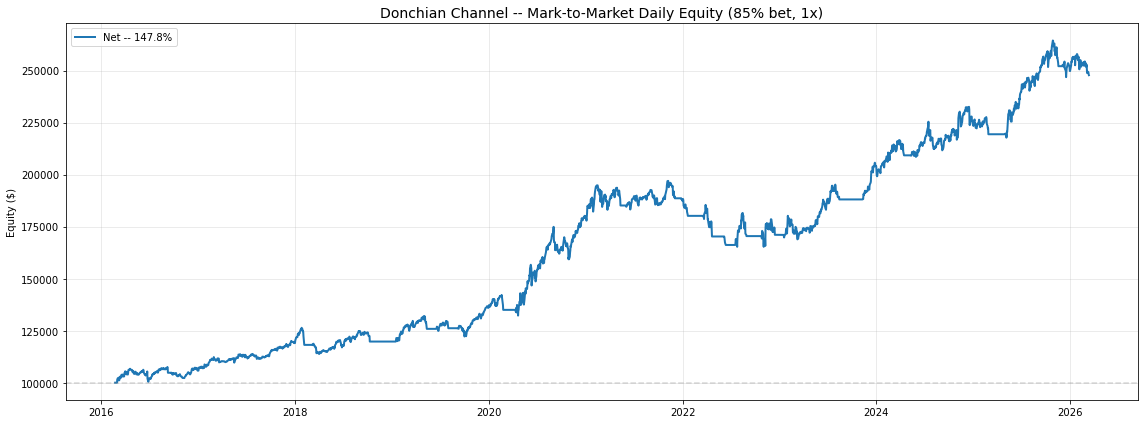

Final equity: $247,777
Total return: 147.8%
Max drawdown: -16.1%


In [55]:
# Plot mark-to-market daily equity
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Net -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"Donchian Channel -- Mark-to-Market Daily Equity ({BET_SIZE:.0%} bet, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")


## 7. Per-Instrument Breakdown & Exit Reason Analysis

In [56]:
for sym in SYMBOLS:
    subset = raw_trades[raw_trades["instrument"] == sym]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    total_ret = ((1 + subset["pct_return_gross"]).prod() - 1) * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    print(f"\n{sym}: {n} trades, WR={wins/n*100:.1f}%, Avg Return={avg_ret:+.3f}%, "
          f"Total={total_ret:+.1f}%, Avg Hold={avg_hold:.1f} days")

print("\n" + "=" * 60)
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    subset = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = subset["pct_return_gross"].mean() * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    wins = (subset["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(subset):3d}, WR={wins/len(subset)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")


SPY: 26 trades, WR=80.8%, Avg Return=+4.357%, Total=+188.9%, Avg Hold=99.0 days

QQQ: 26 trades, WR=69.2%, Avg Return=+5.149%, Total=+227.7%, Avg Hold=97.4 days

IWM: 28 trades, WR=60.7%, Avg Return=+3.613%, Total=+147.1%, Avg Hold=86.1 days

EXIT REASON ANALYSIS
  lower_channel   n= 75, WR=75%, avg return: +5.18%, avg hold: 99d
  stop_loss       n=  5, WR=0%, avg return: -8.00%, avg hold: 18d


## 8. Overlap Analysis

Trend breakouts on SPY/QQQ/IWM are likely highly correlated.
If overlap is >70%, simplify to SPY-only.

ENTRY DATE OVERLAP (within +/-3 business days)
  QQQ<->SPY: 15 overlapping entries (58% of QQQ's 26, 58% of SPY's 26)
  IWM<->SPY: 12 overlapping entries (43% of IWM's 28, 46% of SPY's 26)
  IWM<->QQQ: 10 overlapping entries (36% of IWM's 28, 38% of QQQ's 26)

DAILY IN-POSITION CORRELATION
      SPY   QQQ   IWM
SPY  1.00  0.71  0.63
QQQ  0.71  1.00  0.49
IWM  0.63  0.49  1.00

CONCURRENT POSITION STATS
  Days with ANY position:     2110 / 2624 (80.4%)
  Days with 2+ positions:     1895 / 2624 (72.2%)
  Days with all 3:            1454 / 2624 (55.4%)
  Share of active that are all-3: 68.9%


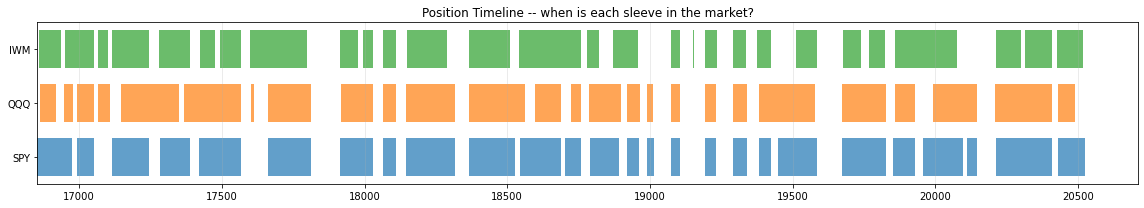


Avg pairwise in-position correlation = 0.61
-> Moderate overlap. Multi-sleeve adds some diversification.


In [57]:
all_dates = pd.date_range(
    raw_trades["entry_time"].min(),
    raw_trades["exit_time"].max(),
    freq="B",
)
in_pos = pd.DataFrame(0, index=all_dates, columns=SYMBOLS)

for _, t in raw_trades.iterrows():
    sym = t["instrument"]
    mask = (in_pos.index >= t["entry_time"]) & (in_pos.index <= t["exit_time"])
    in_pos.loc[mask, sym] = 1

print("=" * 70)
print("ENTRY DATE OVERLAP (within +/-3 business days)")
print("=" * 70)
entries_by_sym = {
    sym: raw_trades[raw_trades["instrument"] == sym]["entry_time"].dt.normalize()
    for sym in SYMBOLS
}
for a in SYMBOLS:
    for b in SYMBOLS:
        if a >= b:
            continue
        matches = 0
        for ea in entries_by_sym[a]:
            if ((entries_by_sym[b] - ea).abs() <= pd.Timedelta(days=3)).any():
                matches += 1
        n_a, n_b = len(entries_by_sym[a]), len(entries_by_sym[b])
        pct_a = matches / n_a * 100 if n_a else 0
        pct_b = matches / n_b * 100 if n_b else 0
        print(f"  {a}<->{b}: {matches} overlapping entries "
              f"({pct_a:.0f}% of {a}'s {n_a}, {pct_b:.0f}% of {b}'s {n_b})")

print("\n" + "=" * 70)
print("DAILY IN-POSITION CORRELATION")
print("=" * 70)
corr_matrix = in_pos.corr()
print(corr_matrix.round(2).to_string())

print("\n" + "=" * 70)
print("CONCURRENT POSITION STATS")
print("=" * 70)
total_days = len(in_pos)
any_pos = (in_pos.sum(axis=1) > 0).sum()
all_3 = (in_pos.sum(axis=1) == 3).sum()
two_plus = (in_pos.sum(axis=1) >= 2).sum()
print(f"  Days with ANY position:    {any_pos:5d} / {total_days} ({any_pos/total_days*100:.1f}%)")
print(f"  Days with 2+ positions:    {two_plus:5d} / {total_days} ({two_plus/total_days*100:.1f}%)")
print(f"  Days with all 3:           {all_3:5d} / {total_days} ({all_3/total_days*100:.1f}%)")
if any_pos:
    print(f"  Share of active that are all-3: {all_3/any_pos*100:.1f}%")

# Gantt timeline
fig, ax = plt.subplots(figsize=(16, 3))
for i, sym in enumerate(SYMBOLS):
    sym_trades = raw_trades[raw_trades["instrument"] == sym]
    for _, t in sym_trades.iterrows():
        ax.barh(i, (t["exit_time"] - t["entry_time"]).days,
                left=t["entry_time"], height=0.7, color=f"C{i}", alpha=0.7)
ax.set_yticks(range(len(SYMBOLS)))
ax.set_yticklabels(SYMBOLS)
ax.set_title("Position Timeline -- when is each sleeve in the market?")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

# Verdict
avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"\nAvg pairwise in-position correlation = {avg_corr:.2f}")
if avg_corr > 0.7:
    print("-> HIGH overlap. Consider simplifying to SPY-only.")
elif avg_corr > 0.4:
    print("-> Moderate overlap. Multi-sleeve adds some diversification.")
else:
    print("-> Low overlap. Multi-sleeve structure earns its keep.")

## 9. Save Standardized Trades

Run `Donchian_Channel_Implementation.ipynb` for sizing comparison.

In [58]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades -> results/{SAVE_NAME}_trades.csv")

summary = {
    "strategy":    STRATEGY_NAME,
    "instruments": SYMBOLS,
    "portfolio":   "long_term",
    "period":      f"{START_DATE} -> {END_DATE}",
    "params":      {k: v for k, v in DEFAULT_PARAMS.items()},
    "trades":      len(raw_trades),
    "has_stop":    DEFAULT_PARAMS.get("stop_loss") is not None,
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary -> results/{SAVE_NAME}_summary.json")
print(f"\nNext: run Donchian_Channel_Implementation.ipynb for sizing comparison")

Saved 80 standardized trades -> results/donchian_channel_trades.csv
Saved summary -> results/donchian_channel_summary.json

Next: run Donchian_Channel_Implementation.ipynb for sizing comparison
